# ResNET Experiments

## Imports

In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))

import torch
from torch import nn
from torchvision import models
from src.data import createDataset, createDataLoader, train_transforms, val_transforms

torch.manual_seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cuda


## Dataset and Dataloader

In [2]:
train_dataset = createDataset(
    path='../dataset/train',
    transform=train_transforms
)

val_dataset = createDataset(
    path='../dataset/val',
    transform=val_transforms
)

train_dataloader = createDataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

val_dataloader = createDataLoader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=True
)

## ResNET model (frozen)

In [3]:
resnet_model = models.resnet18(weights="DEFAULT")
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 4)

for param in resnet_model.parameters():
    param.requires_grad = False

for param in resnet_model.fc.parameters():
    param.requires_grad = True

resnet_model = resnet_model.to(device)

In [4]:
from src.metrics import create_metrics
from src.engine import fit

train_metrics = create_metrics(num_classes=4)
val_metrics = create_metrics(num_classes=4)

for metric in train_metrics.values():
    metric = metric.to(device)
for metric in val_metrics.values():
    metric = metric.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)
epochs = 20

df1 = fit(
    model=resnet_model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_metrics=train_metrics,
    val_metrics=val_metrics,
    epochs=epochs,
    device=device,
    file_path='../models/ResNET_Frozen.pt'
)

Epoch 1/20:
Training Loss: 1.1923 | Training Accuracy: 48.59% | Training Precision: 49.26% | Training Recall: 48.59%
Validation Loss: 1.0419 | Validation Accuracy: 63.30% | Validation Precision: 65.40% | Validation Recall: 63.30%
Best model saved! Val Acc: 63.30%


Epoch 2/20:
Training Loss: 0.9360 | Training Accuracy: 70.36% | Training Precision: 70.40% | Training Recall: 70.36%
Validation Loss: 0.8509 | Validation Accuracy: 74.73% | Validation Precision: 74.85% | Validation Recall: 74.73%
Best model saved! Val Acc: 74.73%


Epoch 3/20:
Training Loss: 0.7813 | Training Accuracy: 76.43% | Training Precision: 76.44% | Training Recall: 76.43%
Validation Loss: 0.7436 | Validation Accuracy: 77.86% | Validation Precision: 78.78% | Validation Recall: 77.86%
Best model saved! Val Acc: 77.86%


Epoch 4/20:
Training Loss: 0.6987 | Training Accuracy: 79.15% | Training Precision: 79.28% | Training Recall: 79.15%
Validation Loss: 0.6648 | Validation Accuracy: 79.64% | Validation Precision: 79.81% 

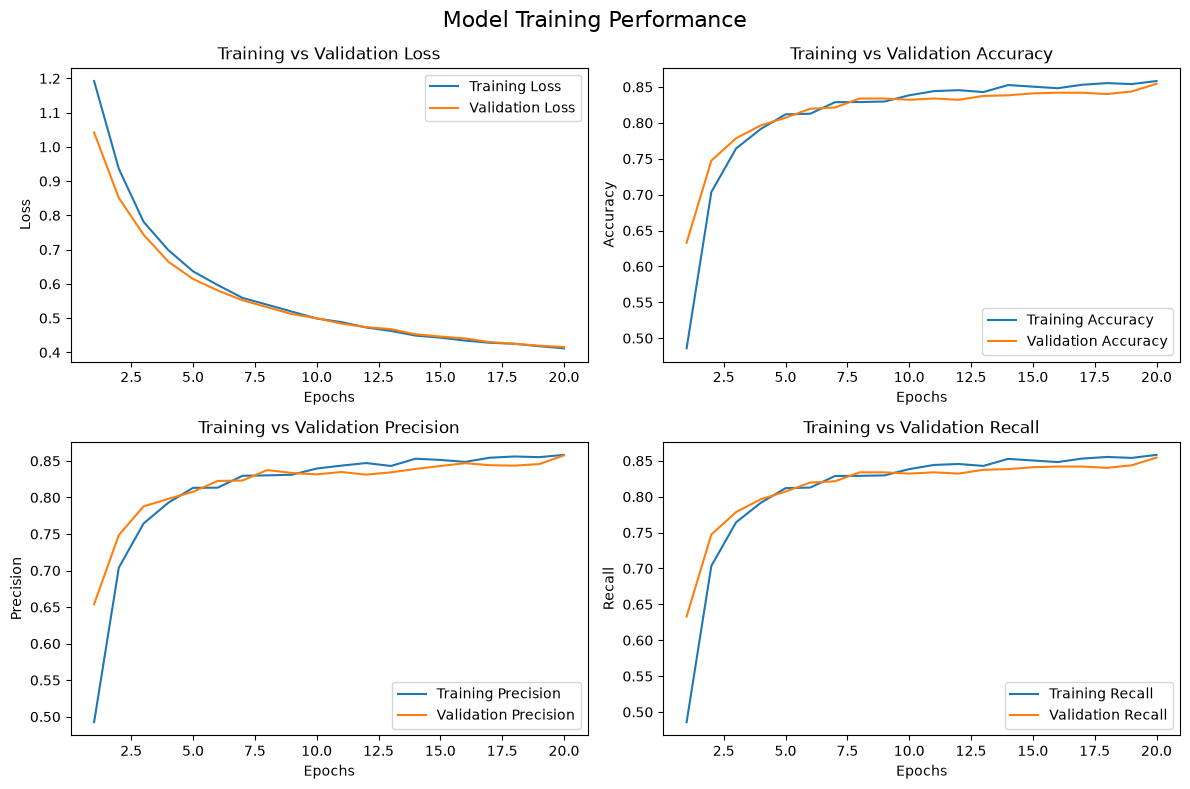

In [5]:
from src.plots import plot_all_metrics
plot_all_metrics(df1)

# ResNET Partial Fine-Tuning

In [6]:
resnet_model_partialFT = models.resnet18(weights="DEFAULT")
resnet_model_partialFT.fc = nn.Linear(resnet_model_partialFT.fc.in_features, 4)

resnet_model_partialFT.load_state_dict(
    torch.load('../models/ResNET_Frozen.pt')
)

for param in resnet_model_partialFT.parameters():
    param.requires_grad = False

for param in resnet_model_partialFT.fc.parameters():
    param.requires_grad = True

for param in resnet_model_partialFT.layer4.parameters():
    param.requires_grad = True

resnet_model_partialFT = resnet_model_partialFT.to(device)

In [7]:
from src.metrics import create_metrics
from src.engine import fit

train_metrics = create_metrics(num_classes=4)
val_metrics = create_metrics(num_classes=4)

for metric in train_metrics.values():
    metric = metric.to(device)
for metric in val_metrics.values():
    metric = metric.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=filter(lambda p: p.requires_grad, resnet_model_partialFT.parameters()),
    lr=1e-5,
    weight_decay=1e-4
)
epochs = 10

df2 = fit(
    model=resnet_model_partialFT,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_metrics=train_metrics,
    val_metrics=val_metrics,
    epochs=epochs,
    device=device,
    file_path='../models/ResNET_Frozen_PartialFT.pt'
)

Epoch 1/10:
Training Loss: 0.3382 | Training Accuracy: 87.90% | Training Precision: 87.97% | Training Recall: 87.90%
Validation Loss: 0.2920 | Validation Accuracy: 89.55% | Validation Precision: 89.71% | Validation Recall: 89.55%
Best model saved! Val Acc: 89.55%


Epoch 2/10:
Training Loss: 0.2425 | Training Accuracy: 91.63% | Training Precision: 91.64% | Training Recall: 91.63%
Validation Loss: 0.2362 | Validation Accuracy: 91.25% | Validation Precision: 91.54% | Validation Recall: 91.25%
Best model saved! Val Acc: 91.25%


Epoch 3/10:
Training Loss: 0.1852 | Training Accuracy: 94.31% | Training Precision: 94.28% | Training Recall: 94.31%
Validation Loss: 0.1960 | Validation Accuracy: 93.12% | Validation Precision: 93.19% | Validation Recall: 93.12%
Best model saved! Val Acc: 93.12%


Epoch 4/10:
Training Loss: 0.1607 | Training Accuracy: 94.44% | Training Precision: 94.43% | Training Recall: 94.44%
Validation Loss: 0.1725 | Validation Accuracy: 94.55% | Validation Precision: 94.53% 

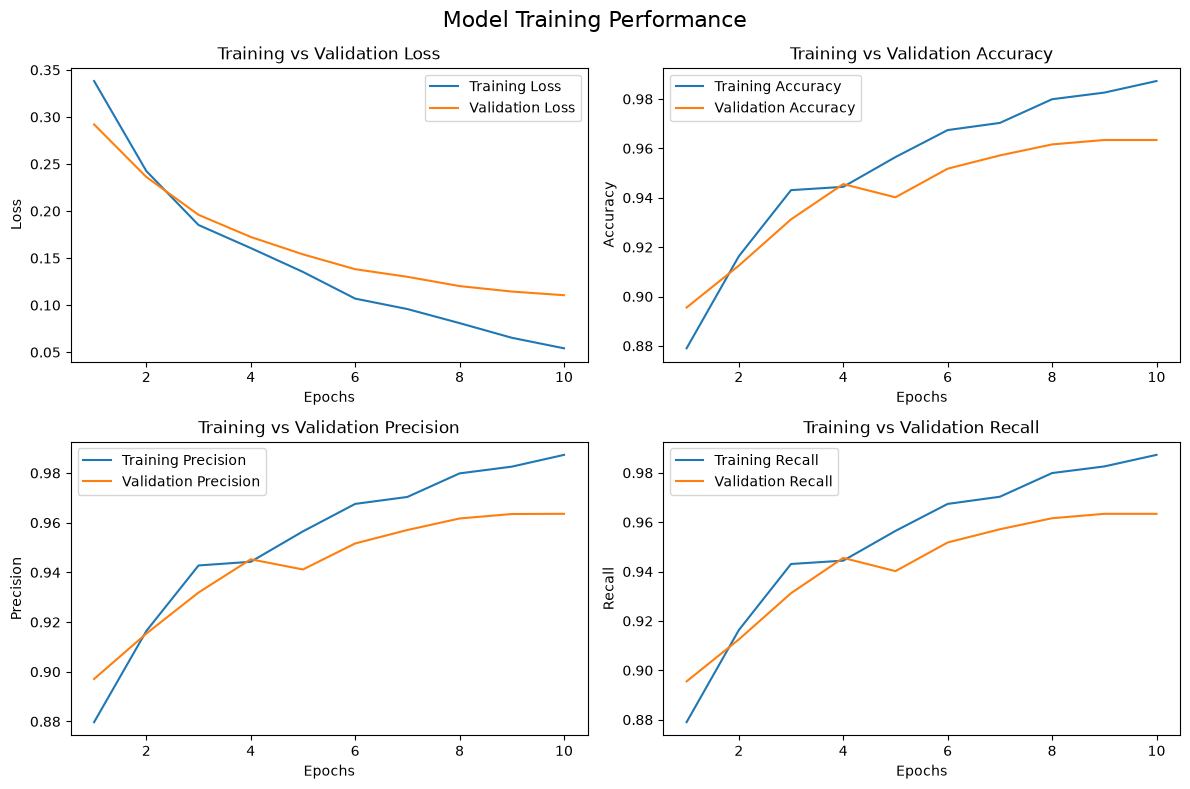

In [8]:
from src.plots import plot_all_metrics
plot_all_metrics(df2)

## ResNET Fine Tuning

In [9]:
resnet_model_FT = models.resnet18(weights="DEFAULT")
resnet_model_FT.fc = nn.Linear(resnet_model_FT.fc.in_features, 4)

resnet_model_FT.load_state_dict(
    torch.load('../models/ResNET_Frozen.pt')
)

for param in resnet_model_FT.parameters():
    param.requires_grad = False

for param in resnet_model_FT.fc.parameters():
    param.requires_grad = True

for param in resnet_model_FT.layer3.parameters():
    param.requires_grad = True

for param in resnet_model_FT.layer4.parameters():
    param.requires_grad = True

resnet_model_FT = resnet_model_FT.to(device)

In [10]:
from src.metrics import create_metrics
from src.engine import fit

train_metrics = create_metrics(num_classes=4)
val_metrics = create_metrics(num_classes=4)

for metric in train_metrics.values():
    metric = metric.to(device)
for metric in val_metrics.values():
    metric = metric.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    [
        {
            "params": resnet_model_FT.layer3.parameters(),
            "lr": 5e-6
        },
        {
            "params": resnet_model_FT.layer4.parameters(),
            "lr": 1e-5
        },
        {
            "params": resnet_model_FT.fc.parameters(),
            "lr": 1e-4
        }
    ],
    weight_decay=1e-4
)
epochs = 10

df3 = fit(
    model=resnet_model_FT,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_metrics=train_metrics,
    val_metrics=val_metrics,
    epochs=epochs,
    device=device,
    file_path='../models/ResNET_Frozen_FT.pt'
)

Epoch 1/10:
Training Loss: 0.3328 | Training Accuracy: 87.68% | Training Precision: 87.77% | Training Recall: 87.68%
Validation Loss: 0.2724 | Validation Accuracy: 90.18% | Validation Precision: 90.54% | Validation Recall: 90.18%
Best model saved! Val Acc: 90.18%


Epoch 2/10:
Training Loss: 0.2292 | Training Accuracy: 92.14% | Training Precision: 92.18% | Training Recall: 92.14%
Validation Loss: 0.2065 | Validation Accuracy: 93.13% | Validation Precision: 93.20% | Validation Recall: 93.13%
Best model saved! Val Acc: 93.13%


Epoch 3/10:
Training Loss: 0.1643 | Training Accuracy: 94.58% | Training Precision: 94.60% | Training Recall: 94.58%
Validation Loss: 0.1692 | Validation Accuracy: 94.11% | Validation Precision: 94.12% | Validation Recall: 94.11%
Best model saved! Val Acc: 94.11%


Epoch 4/10:
Training Loss: 0.1381 | Training Accuracy: 95.58% | Training Precision: 95.58% | Training Recall: 95.58%
Validation Loss: 0.1479 | Validation Accuracy: 95.18% | Validation Precision: 95.17% 

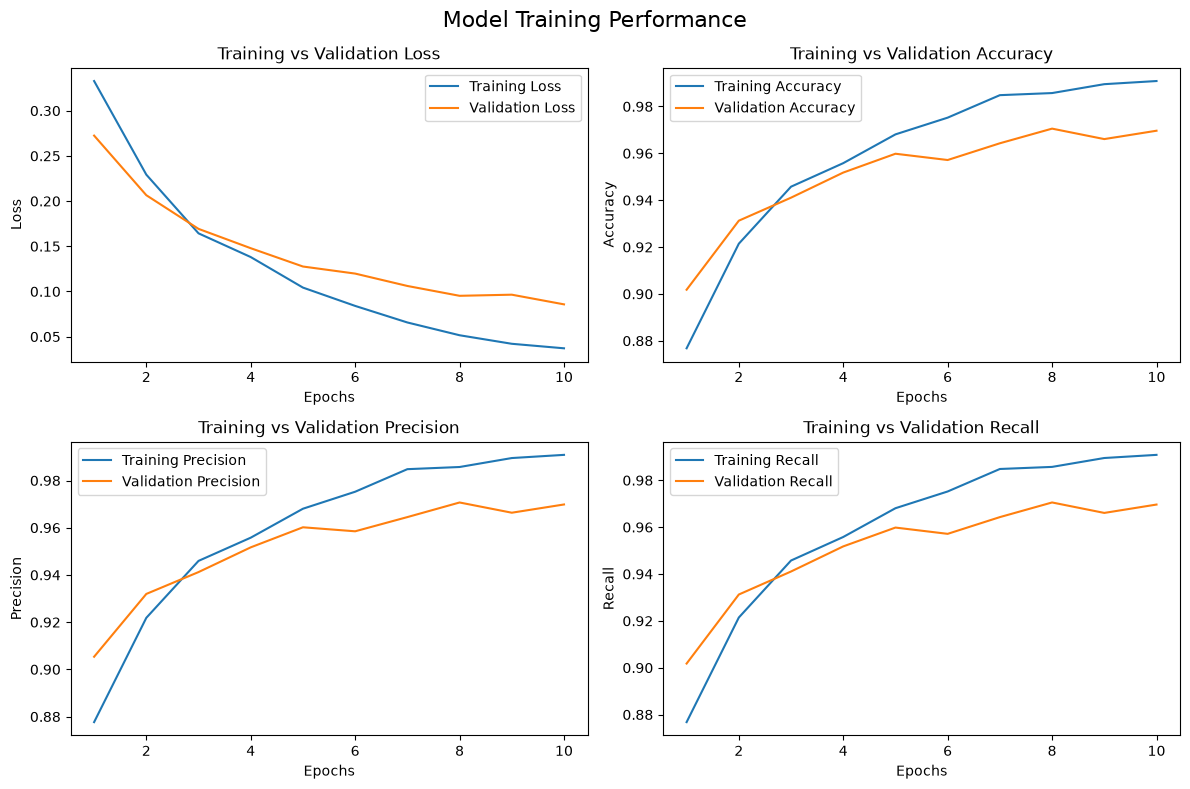

In [11]:
from src.plots import plot_all_metrics
plot_all_metrics(df3)